In [1]:
import os
import cv2
import random
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
np.random.seed(42)
random.seed(42)
IMG_SIZE = (222, 222)
DATASETS = [
    'local_dataset',
    'paddy-disease-classification-healthy',
    'paddy-disease-classification/train_images',
    'leaf-rice-disease-indonesia',
    'rice_leaves_disease'
]

In [3]:
# Load data
def load_images_from_directory(dataset):
    base_path = f'datasets/{dataset}'
    data = []
    labels = os.listdir(base_path)
    for i, label in enumerate(labels):
        label_path = os.path.join(base_path, label)
        images = os.listdir(label_path)
        random_image_pos = random.randint(0, len(images))
        for j, image in enumerate(images):
            if j == random_image_pos:
                image_path = os.path.join(label_path, image)
                img = cv2.imread(image_path)
                if img is None:
                    print(f"Failed to load image: {image_path}")
                    continue
                data.append(cv2.resize(img, IMG_SIZE))
                break
    
    if len(labels) < 5:
        cols = len(labels)
        row = 2
    else:
        cols = 5
        row = (len(labels) // 5)+1
    
    fig = plt.figure(figsize=(3*cols, 3*row))
    fig.suptitle(dataset, fontsize=16)

    for j in range(len(labels)):
        fig.add_subplot(row, cols, j+1)
        plt.imshow(cv2.cvtColor(data[j], cv2.COLOR_BGR2RGB))
        plt.axis('off') 
        plt.title(labels[j])
    print(len(data), labels)

Loading dataset from local_dataset
5 ['Bacterialblight', 'Blast', 'Brownspot', 'Healthy', 'Tungro']
Loading dataset from paddy-disease-classification-healthy
1 ['normal']
Loading dataset from paddy-disease-classification/train_images
10 ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']
Loading dataset from leaf-rice-disease-indonesia
3 ['bacterial_leaf_blight', 'blast', 'tungro']
Loading dataset from rice_leaves_disease
8 ['bacterial_leaf_blight', 'blast', 'brown_spot', 'Leaf scald', 'Narrow Brown Leaf Spot', 'normal', 'Rice Hispa', 'Sheath Blight']


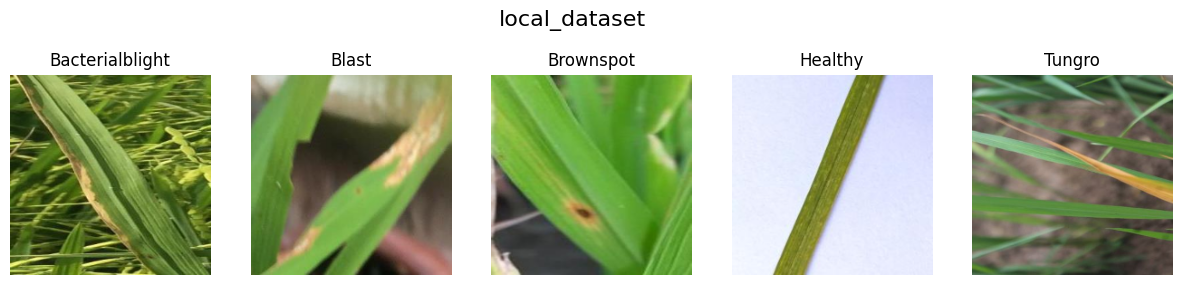

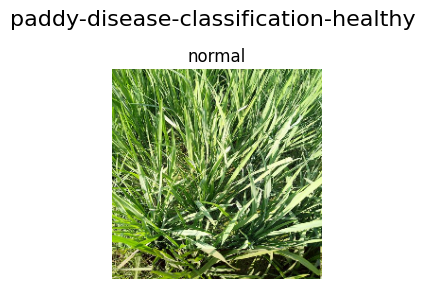

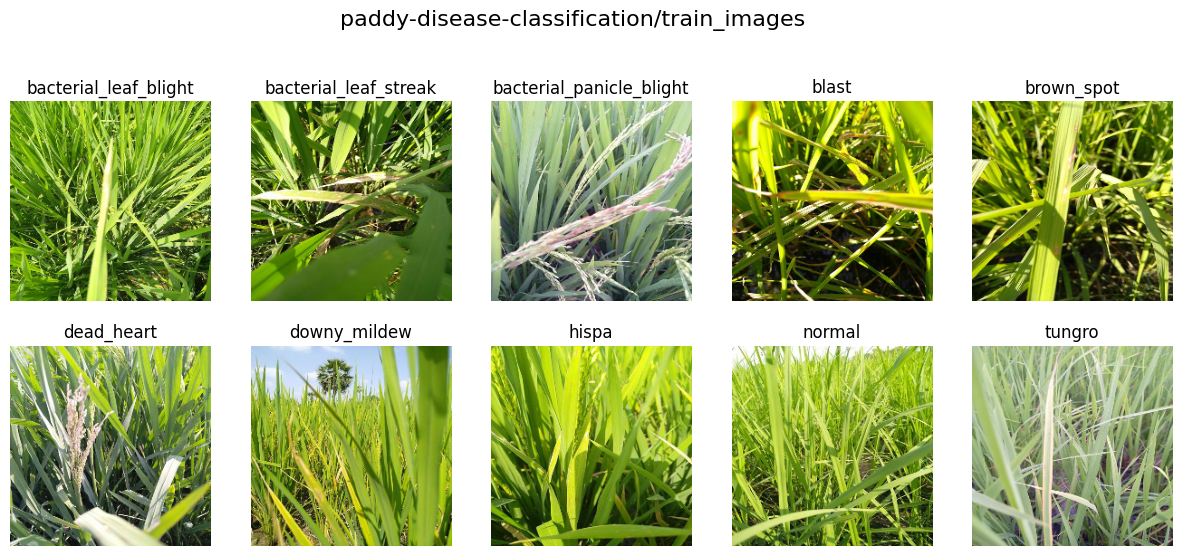

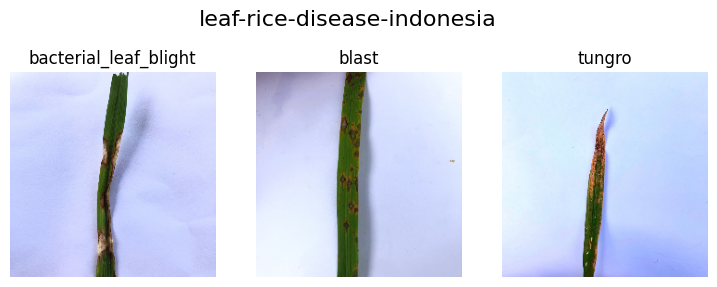

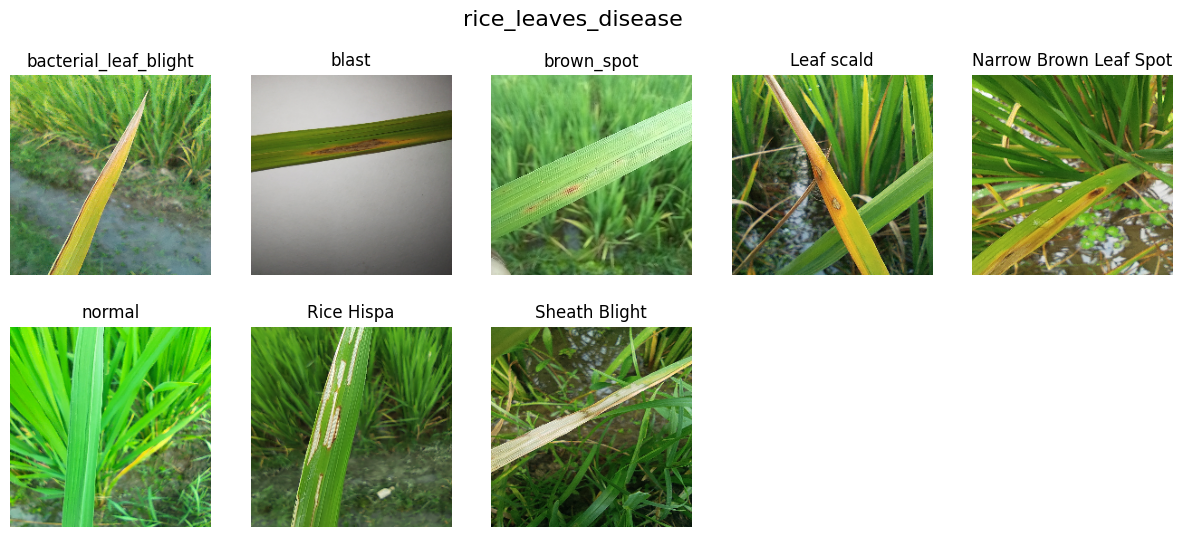

In [8]:
for dataset in DATASETS:
    print(f"Loading dataset from {dataset}")
    load_images_from_directory(dataset)